# II. MATTER POWER SENSITIVITY

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import camb
from camb.symbolic import *
from camb import model

In [2]:
pars = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, lmax=3000,halofit_version='mead'
)

In [3]:
pars.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)
results = camb.get_results(pars)
k, z, Pk = results.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)


In [ ]:
# Changing A_s by +/-10%
A_s_pars_plus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, 
    As=2e-9 * 1.10, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer=True
)
A_s_pars_plus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

A_s_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, 
    As=2e-9 * 0.90, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer=True
)
A_s_pars_minus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

# Computing results for this parameter
A_s_results_plus = camb.get_results(A_s_pars_plus)
A_s_results_minus = camb.get_results(A_s_pars_minus)

A_s_k_plus, A_s_z_plus, A_s_Pk_plus = A_s_results_plus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)
A_s_k_minus, A_s_z_minus, A_s_Pk_minus = A_s_results_minus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

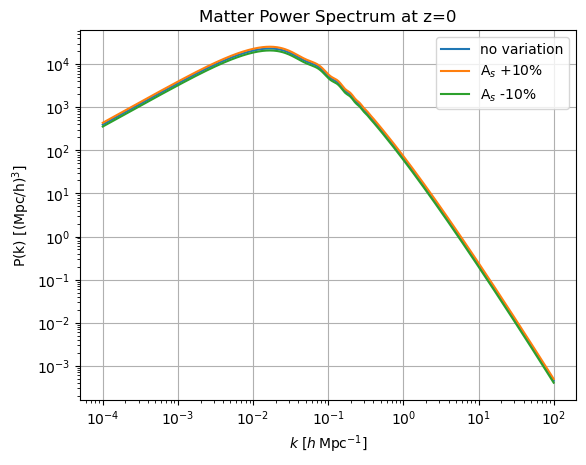

In [11]:
# Plotting power spectrum with varying A_s
plt.figure()
plt.loglog(k, Pk[0, :],label= 'no variation')
plt.loglog(A_s_k_plus, A_s_Pk_plus[0, :], label=r'A$_s$ +10%')
plt.loglog(A_s_k_minus, A_s_Pk_minus[0, :], label=r'A$_s$ -10%')
plt.legend()
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel('P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

**$A_s$ (Primordial Scalar Amplitude)**

Varying the primordial amplitude $A_s$ acts as a global normalization factor for the primordial power spectrum. Consequently, its effect on the linear matter power spectrum is completely scale-independent. We observe in the plot that this results in a constant vertical shift across all $k$ values, without altering the shape of the spectrum.

In [8]:
# Changing n_s by +/-10%

Ns_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965 * 1.10, halofit_version='mead', lmax=3000,WantTransfer=True
)
Ns_pars_plus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

Ns_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965 * 0.90, halofit_version='mead', lmax=3000,WantTransfer=True
)
Ns_pars_minus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

# Computing results for this parameter
Ns_results_plus = camb.get_results(Ns_pars_plus)
Ns_results_minus = camb.get_results(Ns_pars_minus)

Ns_k_plus, Ns_z_plus, Ns_Pk_plus = Ns_results_plus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)
Ns_k_minus, Ns_z_minus, Ns_Pk_minus = Ns_results_minus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

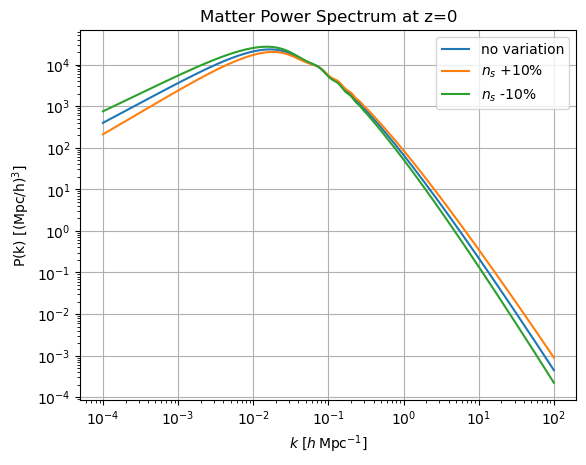

In [10]:
# Plotting power spectrum with varying n_s
plt.figure()
plt.loglog(k, Pk[0, :],label= 'no variation')
plt.loglog(Ns_k_plus, Ns_Pk_plus[0, :], label=r'$n_s$ +10%')
plt.loglog(Ns_k_minus, Ns_Pk_minus[0, :], label=r'$n_s$ -10%')
plt.legend()
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel('P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

**$n_s$ (Scalar Spectral Index)**

By varying the spectral index $n_s$, we observe a modification in the slope (or "tilt") of the primordial power spectrum. Indeed, in the linear regime, the matter power spectrum is given by:
$$P_m(k,z) \propto A_s \left(\frac{k}{k_0}\right)^{n_s - 1} T^2(k) D^2(z)$$
where $T(k)$ is the transfer function (determined by the physics of baryonic matter and neutrinos) and $D(z)$ is the linear growth factor.

Increasing $n_s$: A higher value (e.g., a +10% variation) leads to a more pronounced tilt, resulting in more power on small scales ($k > k_0$) and less power on large scales ($k < k_0$).

Decreasing $n_s$: Conversely, reducing $n_s$ increases the power on large scales and decreases it on small scales.Throughout these variations, the underlying shape of the transfer function, $T(k)$, remains completely unaltered, as it is strictly independent of $n_s$.

In [12]:
# Changing tau by +/-10%

tau_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06 * 1.10, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer = True
)
tau_pars_plus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)
tau_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06 * 0.90, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer = True
)
tau_pars_minus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

# Computing results for this parameter
tau_results_plus = camb.get_results(tau_pars_plus)
tau_results_minus = camb.get_results(tau_pars_minus)

tau_k_plus, tau_z_plus, tau_Pk_plus = tau_results_plus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)
tau_k_minus, tau_z_minus, tau_Pk_minus = tau_results_minus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

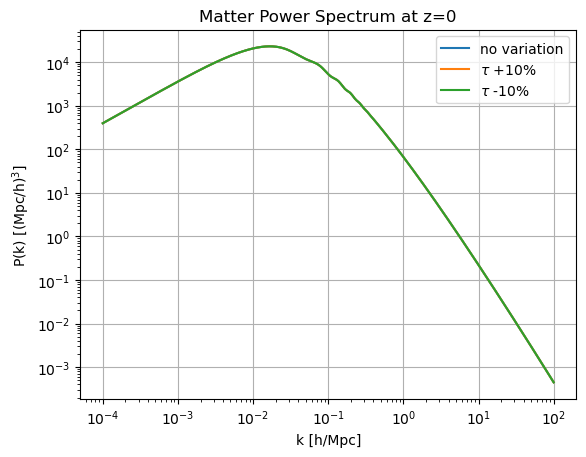

In [23]:
# Plotting power spectrum with varying tau
plt.figure()
plt.loglog(k, Pk[0, :],label= 'no variation')
plt.loglog(tau_k_plus, tau_Pk_plus[0, :], label=r'$\tau$ +10%')
plt.loglog(tau_k_minus, tau_Pk_minus[0, :], label=r'$\tau$ -10%')
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

**$\tau$ (Optical Depth to Reionization)**

Modifying the optical depth to reionization, $\tau$, has an extremely weak effect on the matter power spectrum, $P(k)$, at $z=0$.
This is theoretically expected: in the linear regime, the gravitational growth of structure does not depend directly on $\tau$, but rather on primordial and density parameters such as $(A_s, n_s, \Omega_m h^2, \Omega_b h^2, \dots)$. Indeed, the primary physical role of $\tau$ is to exponentially damp the primary CMB anisotropies via a factor of $e^{-2\tau}$. Consequently, as long as the primordial amplitude $A_s$ is manually held fixed, the matter power spectrum is not significantly altered.

Thus, we observe that even a relatively large variation (e.g., 10%) in $\tau$ does not appreciably modify either the overall amplitude or the underlying shape of $P(k)$. This physically confirms that $\tau$ is a parameter constrained almost entirely by the CMB, rather than by the large-scale matter distribution at $z=0$.

In [15]:
# Changing H0 by +/-10%

H0_pars_plus  = camb.set_params(
    H0=67.5 * 1.10, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer = True
)
H0_pars_minus = camb.set_params(
    H0=67.5 * 0.90, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer = True
)
H0_pars_minus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)
H0_pars_plus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

# Calculating results for this parameter
H0_results_plus = camb.get_results(H0_pars_plus)
H0_results_minus = camb.get_results(H0_pars_minus)

H0_k_plus, H0_z_plus, H0_Pk_plus = H0_results_plus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)
H0_k_minus, H0_z_minus, H0_Pk_minus = H0_results_minus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

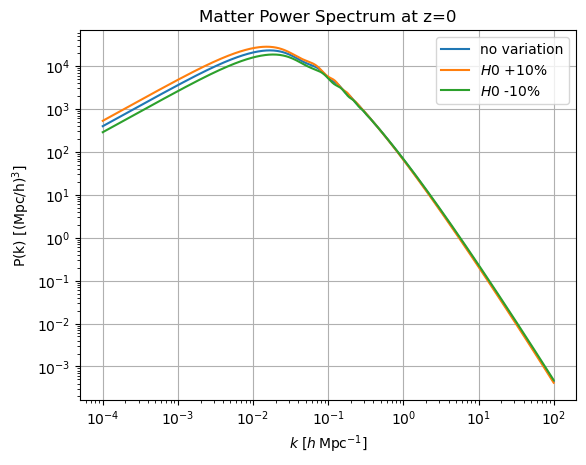

In [16]:
# Plotting power spectrum with varying H0
plt.figure()
plt.loglog(k, Pk[0, :],label= 'no variation')
plt.loglog(H0_k_plus, H0_Pk_plus[0, :], label=r'$H0$ +10%')
plt.loglog(H0_k_minus, H0_Pk_minus[0, :], label=r'$H0$ -10%')
plt.legend()
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r'P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

**$H_0$ (Hubble Constant)**

Varying the value of the Hubble constant, $H_0$, by $\pm 10\%$, we observe that the matter power spectrum, $P(k)$, is not primarily rescaled in amplitude; rather, it undergoes a horizontal shift along the $k$-axis.

This occurs because $H_0$ (parameterized via $h$) is directly tied to the characteristic comoving horizon scale at matter-radiation equality, $k_{\rm eq} \propto \Omega_m h^2$. Consequently, modifying $H_0$ alters this scale, thereby shifting the physical position of the spectrum's turnover.

In [18]:
# Changing Omega_b by +/-10%

omega_b_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022*1.10, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer = True
)
omega_b_pars_plus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)
omega_b_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022*0.90, omch2=0.122, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer = True
)
omega_b_pars_minus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

# Calculating results for this parameter
omega_b_results_plus = camb.get_results(omega_b_pars_plus)
omega_b_results_minus = camb.get_results(omega_b_pars_minus)

omega_b_k_plus, omega_b_z_plus, omega_b_Pk_plus = omega_b_results_plus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)
omega_b_k_minus, omega_b_z_minus, omega_b_Pk_minus = omega_b_results_minus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

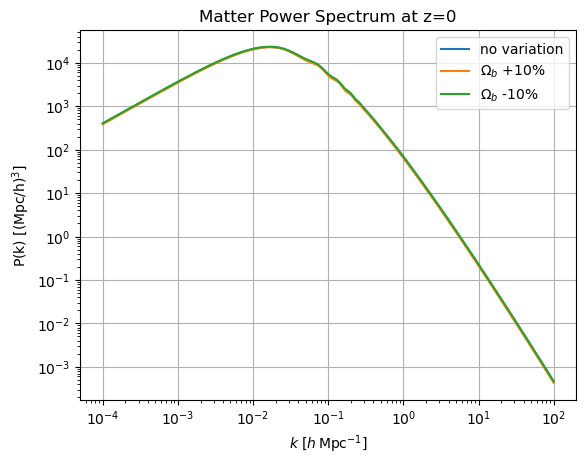

In [20]:
# Plotting power spectrum with varying Omega_b
plt.figure()
plt.loglog(k, Pk[0, :],label= 'no variation')
plt.loglog(omega_b_k_plus, omega_b_Pk_plus[0, :], label=r'$\Omega_b$ +10%')
plt.loglog(omega_b_k_minus, omega_b_Pk_minus[0, :], label=r'$\Omega_b$ -10%')
plt.legend()
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r'P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

**$\Omega_b$ (Baryon Density)**

A variation in $\Omega_b$ modifies the baryon fraction relative to the total matter content ($f_b = \Omega_b/\Omega_m$), which in turn alters the transfer function, $T(k)$. The primary effects on the matter power spectrum are as follows:

- **BAO Contrast**: As $\Omega_b$ increases, the Baryon Acoustic Oscillations (BAO) become slightly more pronounced. This occurs because baryons add inertia to the primordial plasma, altering the acoustic dynamics prior to recombination.

- **BAO Scale**: The comoving sound horizon at the drag epoch, $r_s$, decreases weakly as $\Omega_b$ increases. Consequently, the acoustic oscillations shift slightly toward higher $k$ values (smaller physical scales). However, for a $\pm 10\%$ variation in $\Omega_b$, this shift is quite subtle, on the order of just a few percent.

- **Small Scales**: A larger baryon fraction leads to a slight suppression of power at high $k$. This is a consequence of Silk damping (photon diffusion) acting on the plasma prior to decoupling.

Overall, for a $\pm 10\%$ variation in $\Omega_b$, the global modification to $P(k)$ is modest. The fiducial and varied curves nearly overlap entirely, with the observable differences concentrated specifically around the BAO scales ($k \sim 0.05 - 0.3 \ h/\text{Mpc}$) and at very high $k$.

In [21]:
# Changing Omega_c by +/-10%

omega_c_pars_plus  = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122*1.10, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer= True
)
omega_c_pars_plus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)
omega_c_pars_minus = camb.set_params(
    H0=67.5, ombh2=0.022, omch2=0.122*0.90, mnu=0.06, omk=0, tau=0.06, As=2e-9, ns=0.965, halofit_version='mead', lmax=3000, WantTransfer= True
)
omega_c_pars_minus.set_matter_power(redshifts=[0.0], kmax=200.0, nonlinear=False)

# Calculating results for this parameter
omega_c_results_plus = camb.get_results(omega_c_pars_plus)
omega_c_results_minus = camb.get_results(omega_c_pars_minus)

omega_c_k_plus, omega_c_z_plus, omega_c_Pk_plus = omega_c_results_plus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)
omega_c_k_minus, omega_c_z_minus, omega_c_Pk_minus = omega_c_results_minus.get_matter_power_spectrum(
    minkh=1e-4, maxkh=100.0, npoints=500, var1=model.Transfer_tot, var2=model.Transfer_tot
)

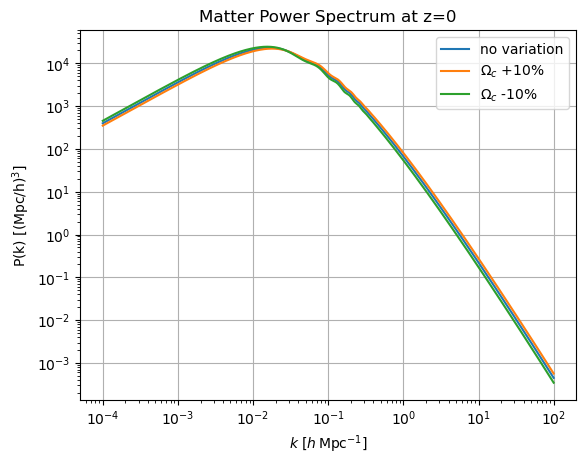

In [22]:
# Plotting power spectrum with varying Omega_c
plt.figure()
plt.loglog(k, Pk[0, :],label= 'no variation')
plt.loglog(omega_c_k_plus, omega_c_Pk_plus[0, :], label=r'$\Omega_c$ +10%')
plt.loglog(omega_c_k_minus, omega_c_Pk_minus[0, :], label=r'$\Omega_c$ -10%')
plt.legend()
plt.xlabel(r"$k\ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r'P(k) [(Mpc/h)$^3$]')
plt.title('Matter Power Spectrum at z=0')
plt.grid(True)
plt.show()

**$\Omega_c$ (Cold Dark Matter Density)**

A $\pm 10\%$ variation in $\Omega_c$ primarily modifies the total matter density, $\Omega_m = \Omega_c + \Omega_b$ (assuming $\Omega_b$ is held fixed).
Because the comoving horizon scale at matter-radiation equality satisfies $k_{\rm eq} \propto \Omega_m h^2$, increasing $\Omega_c$ leads to an earlier epoch of equality (resulting in a larger $k_{\rm eq}$). This shifts the turnover of the matter power spectrum, $P(k)$, toward higher $k$ values. Conversely, decreasing $\Omega_c$ produces the exact opposite effect.
Furthermore, modifying $\Omega_c$ while keeping $\Omega_b$ fixed inherently alters the overall baryon fraction, $f_b = \Omega_b/\Omega_m$. Consequently:

- **Higher** $\Omega_c$: This yields a lower baryon fraction ($f_b$), causing the Baryon Acoustic Oscillations (BAO) to become slightly less pronounced.

- **Lower** $\Omega_c$: This yields a higher baryon fraction ($f_b$), making the BAO features appear slightly more visible.